## Importing libraries

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('Datasets/breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.shape

(569, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Dropping columns

In [6]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [8]:
df['diagnosis'].value_counts()
# df['diagnosis'].apply(lambda x: 1 if x=='M' else 0)

diagnosis
B    357
M    212
Name: count, dtype: int64

In [9]:
df['Mal_1_Ben_0']=df['diagnosis'].apply(lambda x: 1 if x=='M' else 0)

In [10]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Mal_1_Ben_0
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [11]:
df.drop('diagnosis',axis=1,inplace=True)  
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Mal_1_Ben_0
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## EDA

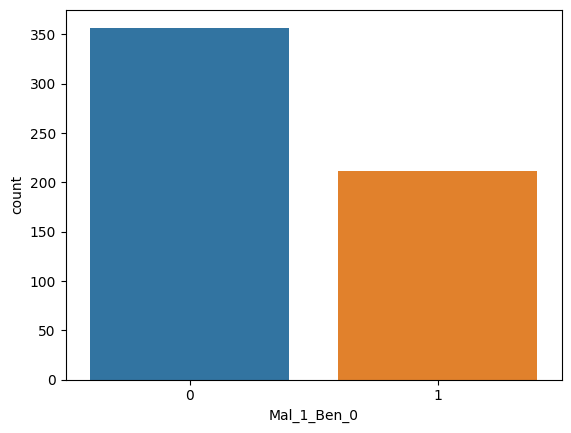

In [12]:
sns.countplot(x='Mal_1_Ben_0',data=df)
plt.show()

<Axes: >

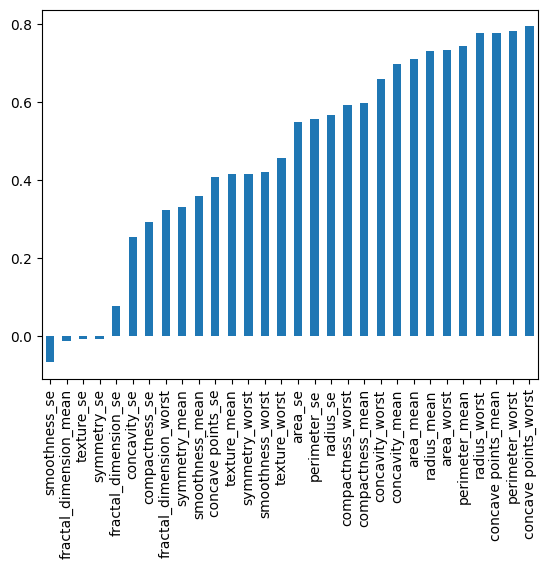

In [21]:
df.corr()['Mal_1_Ben_0'][:-1].sort_values().plot(kind='bar')

## Splitting the data

In [22]:
from sklearn.model_selection import train_test_split

X=df.drop('Mal_1_Ben_0',axis=1).values  
y=df['Mal_1_Ben_0'].values

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=101)

## Scaling

In [23]:
from sklearn.preprocessing import MinMaxScaler 

scaler=MinMaxScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Training the model

In [27]:
X_train.shape

(426, 30)

In [28]:
from keras.models import Sequential
from keras.layers import Dense,Dropout

model=Sequential()

model.add(Dense(30,activation='relu')) #30 neurons
model.add(Dense(15,activation='relu')) #15 neurons
model.add(Dense(1,activation='sigmoid')) #Sigmoid for binary classification

model.compile(loss='binary_crossentropy',optimizer='adam')

model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test))

Epoch 1/600
14/14 [==============================] - 0s 8ms/step - loss: 0.6777 - val_loss: 0.6746
Epoch 2/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6342 - val_loss: 0.6301
Epoch 3/600
14/14 [==============================] - 0s 3ms/step - loss: 0.5929 - val_loss: 0.5912
Epoch 4/600
14/14 [==============================] - 0s 3ms/step - loss: 0.5600 - val_loss: 0.5560
Epoch 5/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5240 - val_loss: 0.5163
Epoch 6/600
14/14 [==============================] - 0s 2ms/step - loss: 0.4835 - val_loss: 0.4757
Epoch 7/600
14/14 [==============================] - 0s 2ms/step - loss: 0.4436 - val_loss: 0.4305
Epoch 8/600
14/14 [==============================] - 0s 2ms/step - loss: 0.4013 - val_loss: 0.3851
Epoch 9/600
14/14 [==============================] - 0s 2ms/step - loss: 0.3601 - val_loss: 0.3443
Epoch 10/600
14/14 [==============================] - 0s 2ms/step - loss: 0.3249 - val_loss: 0.3093
Epoch 11/

<Axes: >

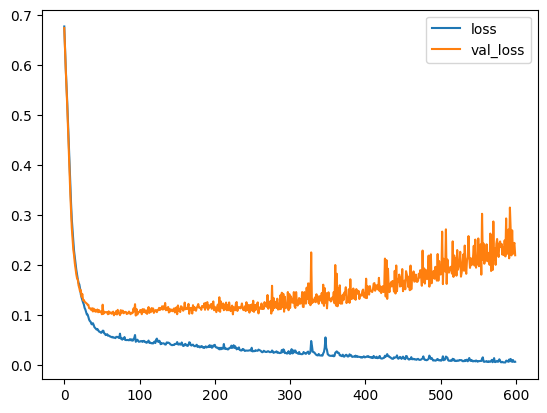

In [29]:
losses=pd.DataFrame(model.history.history)
losses.plot()

Model is overfitting, hence using stopper

In [31]:
from keras.callbacks import EarlyStopping

model=Sequential()

model.add(Dense(30,activation='relu')) #30 neurons
model.add(Dense(15,activation='relu')) #15 neurons
model.add(Dense(1,activation='sigmoid')) #Sigmoid for binary classification

model.compile(loss='binary_crossentropy',optimizer='adam')

In [32]:
early_stopper=EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=25)

In [33]:
model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test),callbacks=[early_stopper])

Epoch 1/600
14/14 [==============================] - 1s 23ms/step - loss: 0.6834 - val_loss: 0.6741
Epoch 2/600
14/14 [==============================] - 0s 3ms/step - loss: 0.6635 - val_loss: 0.6550
Epoch 3/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6430 - val_loss: 0.6332
Epoch 4/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6176 - val_loss: 0.6046
Epoch 5/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5788 - val_loss: 0.5570
Epoch 6/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5314 - val_loss: 0.5098
Epoch 7/600
14/14 [==============================] - 0s 2ms/step - loss: 0.4822 - val_loss: 0.4641
Epoch 8/600
14/14 [==============================] - 0s 2ms/step - loss: 0.4400 - val_loss: 0.4185
Epoch 9/600
14/14 [==============================] - 0s 2ms/step - loss: 0.3991 - val_loss: 0.3776
Epoch 10/600
14/14 [==============================] - 0s 2ms/step - loss: 0.3607 - val_loss: 0.3411
Epoch 11

<Axes: >

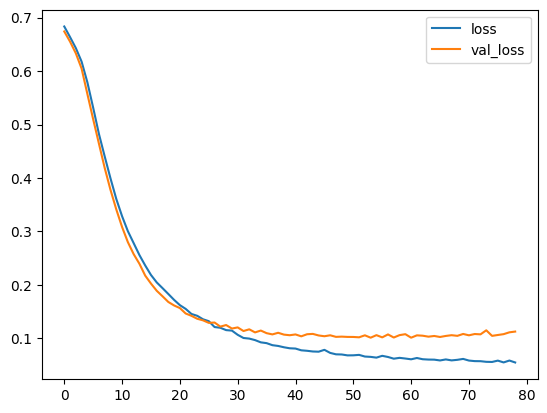

In [34]:
new_loss=pd.DataFrame(model.history.history)
new_loss.plot()

## Using Dropout to reduce overfitting

In [35]:
model=Sequential()

model.add(Dense(30,activation='relu')) #30 neurons
model.add(Dropout(0.5)) #half the neurons will be turned off randomly

model.add(Dense(15,activation='relu')) #15 neurons
model.add(Dropout(0.5)) #half the neurons will be turned off randomly

model.add(Dense(1,activation='sigmoid')) #Sigmoid for binary classification

model.compile(loss='binary_crossentropy',optimizer='adam')

In [36]:
model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test),callbacks=[early_stopper])

Epoch 1/600
14/14 [==============================] - 0s 7ms/step - loss: 0.6801 - val_loss: 0.6675
Epoch 2/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6859 - val_loss: 0.6452
Epoch 3/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6450 - val_loss: 0.6249
Epoch 4/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6305 - val_loss: 0.5979
Epoch 5/600
14/14 [==============================] - 0s 2ms/step - loss: 0.6201 - val_loss: 0.5677
Epoch 6/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5979 - val_loss: 0.5389
Epoch 7/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5616 - val_loss: 0.5142
Epoch 8/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5458 - val_loss: 0.4854
Epoch 9/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5066 - val_loss: 0.4571
Epoch 10/600
14/14 [==============================] - 0s 2ms/step - loss: 0.5077 - val_loss: 0.4257
Epoch 11/

<Axes: >

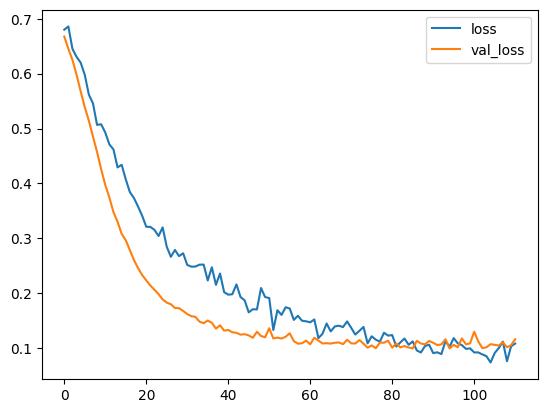

In [37]:
new_loss1=pd.DataFrame(model.history.history)
new_loss1.plot()

## Predicting the test data

In [42]:
predictions = (model.predict(X_test) > 0.5).astype("int32")
predictions

5/5 [==============================] - 0s 557us/step


array([[0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
    

## Evaluation of the model

In [43]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97        88
           1       0.92      0.98      0.95        55

    accuracy                           0.96       143
   macro avg       0.95      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [45]:
print(confusion_matrix(y_test,predictions))

[[83  5]
 [ 1 54]]


<Axes: >

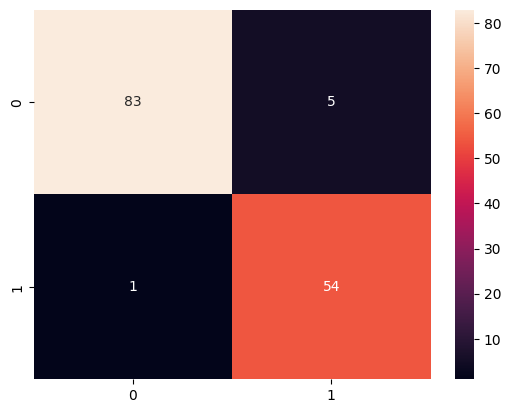

In [46]:
sns.heatmap(confusion_matrix(y_test,predictions),annot=True)